# ABLA — Controlled Ablation of ESN Leak Rate

This notebook isolates the effect of the ESN **leak rate** on multi-temperature
effusivity prediction and reservoir dynamics:

\[
\alpha\in\{0.01,0.05,0.10,0.20,0.30,0.50,0.70,0.90,1.00\}.
\]

The state update is

\[
\mathbf{x}(t)=(1-\alpha)\mathbf{x}(t-1)+
\alpha\tanh\!\left(\mathbf{W}_{in}[1;\mathbf{u}(t)]+\mathbf{W}\mathbf{x}(t-1)\right).
\]

Thus, small values preserve more previous activity and update slowly, whereas values
near one respond strongly to the newly proposed state. The grid deliberately includes
extreme values so under-responsive and highly responsive regimes remain visible.

Everything else is fixed: 20 reservoir units, spectral radius 0.90, input magnitude
1.00, no washout, absolute smoothed inputs, a 0–3 s window, nine summaries per unit,
27 scalar thermal features, fixed XGBoost settings, three reservoir seeds, and the
same 14 leave-one-material-out folds. Every condition therefore supplies the same
207 predictors to the regressor.


# 1. Imports and fixed configuration


In [16]:
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [17]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)

# Broad controlled grid, including intentionally extreme update rates.
LEAK_RATE_VALUES = (0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90, 1.00, 1.50)

FIXED_ESN_PARAMS = {
    "res_size": 20,
    "input_magnitude": 1.00,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 5,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
}

RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True
SUMMARY_NAMES = (
    "mean", "std", "min", "max", "initial",
    "net_change", "slope", "mean_abs", "abs_auc",
)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_leak_rate_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO"

print("Leak rates:", LEAK_RATE_VALUES)
print("Fixed ESN HPs:", FIXED_ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Leak rates: (0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.5)
Fixed ESN HPs: {'res_size': 20, 'input_magnitude': 1.0, 'spectral_radius': 0.9, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Controlled-ablation interpretation

This is not an Optuna or Bayesian search. Every declared leak rate is evaluated
explicitly with the same reservoir size, random seeds, input data, summaries,
thermal features, XGBoost settings, and LOMO folds. The pooled metrics identify an
exploratory best rate; the fold table checks whether that conclusion is consistent
across unseen materials.


# 2. Load trials and assign standard material properties


In [18]:
STANDARD_PROPERTIES = {
    "ps_foam": {"k": .034, "rho": 25., "cp": 1400.},
    "pu_foam": {"k": .043, "rho": 30., "cp": 1400.},
    "cork": {"k": .043, "rho": 240., "cp": 1800.},
    "wood": {"k": .150, "rho": 700., "cp": 1700.},
    "pdms": {"k": .150, "rho": 970., "cp": 1460.},
    "gypsum": {"k": .170, "rho": 800., "cp": 1090.},
    "cement": {"k": .290, "rho": 1440., "cp": 750.},
    "graphite": {"k": 100., "rho": 1820., "cp": 710.},
    "bismuth": {"k": 8.1, "rho": 9780., "cp": 130.},
    "titanium": {"k": 21.9, "rho": 4506., "cp": 523.},
    "nickel": {"k": 90.9, "rho": 8908., "cp": 461.},
    "iron": {"k": 80.4, "rho": 7874., "cp": 449.},
    "aluminum": {"k": 237., "rho": 2700., "cp": 897.},
    "copper": {"k": 401., "rho": 8960., "cp": 385.},
}
ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium", "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron", "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frame["Temperature_C"] = float(temperature.rstrip("C"))
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary", "Temperature_C"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature", "Temperature_C"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one material name does not have a recognized alias.")
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print("Raw trial count:", DATA["trial_id"].nunique())


Raw trial count: 336


# 3. Contact alignment and fixed 0–3 s window


In [19]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=.30, skip_samples=5):
    clean = (
        trial[["Time", "Primary"]].dropna().sort_values("Time")
        .drop_duplicates("Time").reset_index(drop=True)
    )
    time_values = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time_values) <= 0):
        raise ValueError("Invalid sequence for contact detection.")
    time_values, signal = time_values[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal))
    if window % 2 == 0:
        window -= 1
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time_values)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time_values[elbow])


aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 8:
        warnings.warn(f"Skipping {trial_id}: too few samples in 0–3 s.")
        continue
    trial = trial.reset_index(drop=True)
    aligned_trials[trial_id] = trial
    metadata_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })

METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
if METADATA["Sample"].nunique() != 14:
    warnings.warn(f"Expected 14 materials but retained {METADATA['Sample'].nunique()}.")
print("Aligned trials retained:", len(METADATA))
print("Materials retained:", METADATA["Sample"].nunique())


Aligned trials retained: 336
Materials retained: 14


# 4. Absolute-smoothed ESN inputs and variable-leak reservoir

The five channels supplied directly to the ESN are smoothed Primary, smoothed Secondary, their difference, and their two time derivatives. There is no baseline centering, min–max normalization or StandardScaler.


In [20]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def esn_input(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    return np.column_stack([
        primary,
        secondary,
        primary - secondary,
        np.gradient(primary, time_values),
        np.gradient(secondary, time_values),
    ])


class ManualReservoir:
    def __init__(self, leak_rate, random_state):
        self.res_size = int(FIXED_ESN_PARAMS["res_size"])
        self.leak_rate = float(leak_rate)
        self.washout = int(FIXED_ESN_PARAMS["washout"])
        rng = np.random.default_rng(random_state)
        self.Win = (
            rng.random((self.res_size, 1 + 5)) - 0.5
        ) * FIXED_ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * FIXED_ESN_PARAMS["spectral_radius"]

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            proposed = np.tanh(
                self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x
            )
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("The reservoir sequence is shorter than the washout.")
        return states[self.washout:]


def summarize_states(time_values, states):
    time_values = np.asarray(time_values, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_std": float(np.std(x)),
            f"{prefix}_min": float(np.min(x)),
            f"{prefix}_max": float(np.max(x)),
            f"{prefix}_initial": float(x[0]),
            f"{prefix}_net_change": float(x[-1] - x[0]),
            f"{prefix}_slope": float(np.polyfit(time_values, x, 1)[0]),
            f"{prefix}_mean_abs": float(np.mean(np.abs(x))),
            f"{prefix}_abs_auc": float(np.trapezoid(np.abs(x), time_values)),
        })
    return output


# 5. Scalar thermal features over the same 0–3 s interval


In [21]:
THERMAL_SLOPE_WINDOWS = {
    "early": (0.0, 1.0),
    "middle": (1.0, 2.0),
    "late": (2.0, 3.0),
}


def signal_slope(time_values, values, window):
    mask = (time_values >= window[0]) & (time_values <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time_values[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    difference = primary - secondary
    result = {}
    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time_values)
        result[f"thermal_{name}_final_change"] = float(change[-1])
        result[f"thermal_{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"thermal_{name}_response_auc"] = float(np.trapezoid(np.abs(change), time_values))
        result[f"thermal_{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"thermal_{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time_values))
        for window_name, window in THERMAL_SLOPE_WINDOWS.items():
            result[f"thermal_{name}_{window_name}_slope"] = signal_slope(
                time_values, signal, window
            )

    primary_auc = result["thermal_primary_response_auc"]
    result["thermal_secondary_primary_auc_ratio"] = (
        result["thermal_secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["thermal_initial_sensor_difference"] = float(difference[0])
    result["thermal_final_sensor_difference"] = float(difference[-1])
    return result


THERMAL_FEATURES = pd.DataFrame([
    {"trial_id": trial_id, **extract_thermal_features(trial)}
    for trial_id, trial in aligned_trials.items()
]).set_index("trial_id").sort_index()
print("Scalar thermal predictors:", THERMAL_FEATURES.shape[1])
display(THERMAL_FEATURES.head())


Scalar thermal predictors: 27


,thermal_primary_final_change,thermal_primary_max_abs_change,thermal_primary_response_auc,thermal_primary_max_abs_rate,thermal_primary_rate_auc,thermal_primary_early_slope,thermal_primary_middle_slope,thermal_primary_late_slope,thermal_secondary_final_change,thermal_secondary_max_abs_change,...,thermal_difference_max_abs_change,thermal_difference_response_auc,thermal_difference_max_abs_rate,thermal_difference_rate_auc,thermal_difference_early_slope,thermal_difference_middle_slope,thermal_difference_late_slope,thermal_secondary_primary_auc_ratio,thermal_initial_sensor_difference,thermal_final_sensor_difference
trial_id,,,,,,,,,,,,,,,,,,,,,
30C__aluminum_trial_1,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.608193e-07,-2.301865e-07,-7.393007e-07,7.393007e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.999514e-07,1.968456e-07,0.108039,-0.000040,-0.000043
30C__aluminum_trial_2,-0.000003,0.000003,0.000007,0.000004,0.000003,-0.000002,-5.356806e-07,-2.233930e-07,-7.777622e-07,7.777622e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.770283e-07,1.954258e-07,0.126702,-0.000040,-0.000043
30C__aluminum_trial_3,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-4.910211e-07,-2.395687e-07,-8.261538e-07,8.261538e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.242352e-07,1.772203e-07,0.137653,-0.000040,-0.000043
30C__aluminum_trial_4,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.429477e-07,-2.277291e-07,-7.784615e-07,7.784615e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-3.218157e-07,1.910936e-07,0.130203,-0.000040,-0.000043
30C__aluminum_trial_5,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.403697e-07,-2.391434e-07,-8.559441e-07,8.559441e-07,...,0.000002,0.000006,0.000003,0.000003,-0.000002,-3.093597e-07,2.082574e-07,0.151386,-0.000041,-0.000043


# 6. Precompute summarized ESN features for every leak rate and seed


In [22]:
ESN_FEATURES = {}
FEATURE_GENERATION_SECONDS = {}

for leak_rate in LEAK_RATE_VALUES:
    started = time.perf_counter()
    for seed in RESERVOIR_SEEDS:
        print(f"Generating summarized ESN features: LR={leak_rate:.2f}, seed={seed}")
        reservoir = ManualReservoir(leak_rate=leak_rate, random_state=seed)
        rows = []
        for trial_id in METADATA["trial_id"]:
            trial = aligned_trials[trial_id]
            time_values = trial["time_from_contact"].to_numpy(float)
            states = reservoir.run(esn_input(trial))
            state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
            rows.append({"trial_id": trial_id, **summarize_states(state_time, states)})
        esn_table = pd.DataFrame(rows).set_index("trial_id").sort_index()
        ESN_FEATURES[(leak_rate, seed)] = esn_table.join(
            THERMAL_FEATURES, how="left", validate="one_to_one"
        )
    FEATURE_GENERATION_SECONDS[leak_rate] = time.perf_counter() - started

fixed_predictors = len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"] + THERMAL_FEATURES.shape[1]
outer_training_trials = len(METADATA) - int(
    (METADATA["Sample"] == METADATA["Sample"].iloc[0]).sum()
)
FEATURE_COUNTS = pd.DataFrame([
    {
        "leak_rate": leak_rate,
        "reservoir_units": FIXED_ESN_PARAMS["res_size"],
        "esn_predictors": len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"],
        "thermal_predictors": THERMAL_FEATURES.shape[1],
        "total_predictors": fixed_predictors,
        "outer_training_trials": outer_training_trials,
        "predictor_to_training_trial_ratio": fixed_predictors / outer_training_trials,
        "feature_generation_seconds": FEATURE_GENERATION_SECONDS[leak_rate],
    }
    for leak_rate in LEAK_RATE_VALUES
])
display(FEATURE_COUNTS)


Generating summarized ESN features: LR=0.01, seed=42
Generating summarized ESN features: LR=0.01, seed=43
Generating summarized ESN features: LR=0.01, seed=44
Generating summarized ESN features: LR=0.05, seed=42
Generating summarized ESN features: LR=0.05, seed=43
Generating summarized ESN features: LR=0.05, seed=44
Generating summarized ESN features: LR=0.10, seed=42
Generating summarized ESN features: LR=0.10, seed=43
Generating summarized ESN features: LR=0.10, seed=44
Generating summarized ESN features: LR=0.20, seed=42
Generating summarized ESN features: LR=0.20, seed=43
Generating summarized ESN features: LR=0.20, seed=44
Generating summarized ESN features: LR=0.30, seed=42
Generating summarized ESN features: LR=0.30, seed=43
Generating summarized ESN features: LR=0.30, seed=44
Generating summarized ESN features: LR=0.50, seed=42
Generating summarized ESN features: LR=0.50, seed=43
Generating summarized ESN features: LR=0.50, seed=44
Generating summarized ESN features: LR=0.70, s

,leak_rate,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds
0,0.01,20,180,27,207,312,0.663462,1.714606
1,0.05,20,180,27,207,312,0.663462,1.528328
2,0.10,20,180,27,207,312,0.663462,1.254887
3,0.20,20,180,27,207,312,0.663462,1.249690
4,0.30,20,180,27,207,312,0.663462,1.190251
5,0.50,20,180,27,207,312,0.663462,1.231165
6,0.70,20,180,27,207,312,0.663462,1.240938
7,0.90,20,180,27,207,312,0.663462,1.200581
8,1.00,20,180,27,207,312,0.663462,1.236195
9,1.50,20,180,27,207,312,0.663462,1.227397


# 7. Leakage-safe LOMO evaluation at every leak rate


In [23]:
def make_regressor(seed):
    xgb = XGBRegressor(
        objective="reg:squarederror", random_state=int(seed), n_jobs=-1,
        tree_method="hist", verbosity=0, **XGB_PARAMS,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )


def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": float(r2_score(y_true, y_pred)) if target_range > 0 else np.nan,
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


logo = LeaveOneGroupOut()
prediction_rows, fold_rows, evaluation_seconds = [], [], {}

for leak_rate in LEAK_RATE_VALUES:
    started = time.perf_counter()
    print(f"\nEvaluating leak rate {leak_rate:.2f}")
    for fold, (train_idx, test_idx) in enumerate(
        logo.split(METADATA, groups=METADATA["Sample"]), start=1
    ):
        train_meta = METADATA.iloc[train_idx].reset_index(drop=True)
        test_meta = METADATA.iloc[test_idx].reset_index(drop=True)
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        y_train = train_meta[TARGET].to_numpy(float)
        y_test = test_meta[TARGET].to_numpy(float)
        held_out = str(test_meta["Sample"].iloc[0])

        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = ESN_FEATURES[(leak_rate, seed)]
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            prediction = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                prediction = np.clip(prediction, y_train.min(), y_train.max())
            seed_predictions.append(prediction)

        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        fold_rows.append({
            "leak_rate": leak_rate, "fold": fold,
            "held_out_material": held_out, "n": len(y_test),
            "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
            "nrmse_training_range": rmse / float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual / y_test)) * 100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "leak_rate": leak_rate, "fold": fold,
                "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"],
                "Temperature_C": meta_row["Temperature_C"],
                "Sample": meta_row["Sample"], "Trial": meta_row["Trial"],
                "y_true": y_test[row_index], "y_pred": prediction[row_index],
            })
    evaluation_seconds[leak_rate] = time.perf_counter() - started
    print(f"Completed LR={leak_rate:.2f} in {evaluation_seconds[leak_rate]/60:.1f} min")

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"leak_rate": float(leak_rate), **pooled_metrics(part["y_true"], part["y_pred"])}
    for leak_rate, part in OOF.groupby("leak_rate", sort=True)
])
OVERALL["fold_nrmse_sd"] = OVERALL["leak_rate"].map(
    FOLD_METRICS.groupby("leak_rate")["nrmse_training_range"].std(ddof=1)
)
OVERALL["evaluation_seconds"] = OVERALL["leak_rate"].map(evaluation_seconds)
OVERALL = OVERALL.merge(FEATURE_COUNTS, on="leak_rate", how="left", validate="one_to_one")
OVERALL["J_exploratory"] = (
    OVERALL["nrmse_range"] + .10 * (1 - OVERALL["r2"]) + .10 * OVERALL["fold_nrmse_sd"]
)
OVERALL = OVERALL.sort_values("leak_rate").reset_index(drop=True)
display(OVERALL)

best = OVERALL.loc[OVERALL["J_exploratory"].idxmin()]
print(
    f"Exploratory best leak rate: LR={best['leak_rate']:.2f}; "
    f"NRMSE={best['nrmse_range']:.4f}, R²={best['r2']:.4f}, "
    f"J={best['J_exploratory']:.4f}"
)



Evaluating leak rate 0.01
Completed LR=0.01 in 0.2 min

Evaluating leak rate 0.05
Completed LR=0.05 in 0.2 min

Evaluating leak rate 0.10
Completed LR=0.10 in 0.2 min

Evaluating leak rate 0.20
Completed LR=0.20 in 0.2 min

Evaluating leak rate 0.30
Completed LR=0.30 in 0.2 min

Evaluating leak rate 0.50
Completed LR=0.50 in 0.2 min

Evaluating leak rate 0.70
Completed LR=0.70 in 0.2 min

Evaluating leak rate 0.90
Completed LR=0.90 in 0.2 min

Evaluating leak rate 1.00
Completed LR=1.00 in 0.2 min

Evaluating leak rate 1.50
Completed LR=1.50 in 0.2 min


,leak_rate,n,mae,rmse,nrmse_range,r2,median_ape_pct,fold_nrmse_sd,evaluation_seconds,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds,J_exploratory
0,0.01,336,4800.076651,8451.588974,0.227449,0.431403,57.932248,0.271662,13.784716,20,180,27,207,312,0.663462,1.714606,0.311475
1,0.05,336,4655.153576,8308.545355,0.223600,0.450487,55.027990,0.270189,13.748614,20,180,27,207,312,0.663462,1.528328,0.305570
2,0.10,336,4587.241112,8149.497693,0.219320,0.471324,55.043107,0.264257,13.528752,20,180,27,207,312,0.663462,1.254887,0.298613
3,0.20,336,4614.225903,8219.460023,0.221202,0.462208,54.210694,0.265310,14.907555,20,180,27,207,312,0.663462,1.249690,0.301513
4,0.30,336,4520.978480,8116.525269,0.218432,0.475593,51.384683,0.263939,14.102838,20,180,27,207,312,0.663462,1.190251,0.297267
5,0.50,336,4525.026933,8133.280581,0.218883,0.473426,55.296129,0.264076,13.448510,20,180,27,207,312,0.663462,1.231165,0.297948
6,0.70,336,4572.554998,8194.163453,0.220522,0.465513,52.061441,0.264515,13.574784,20,180,27,207,312,0.663462,1.240938,0.300422
7,0.90,336,4772.397980,8411.450195,0.226369,0.436791,54.354610,0.268421,13.519941,20,180,27,207,312,0.663462,1.200581,0.309532
8,1.00,336,4690.766811,8345.635812,0.224598,0.445570,53.162823,0.270347,13.543727,20,180,27,207,312,0.663462,1.236195,0.307076
9,1.50,336,4756.742706,8402.622175,0.226132,0.437972,57.317175,0.270972,12.159865,20,180,27,207,312,0.663462,1.227397,0.309432


Exploratory best leak rate: LR=0.30; NRMSE=0.2184, R²=0.4756, J=0.2973


# 8. Performance and stability versus leak rate


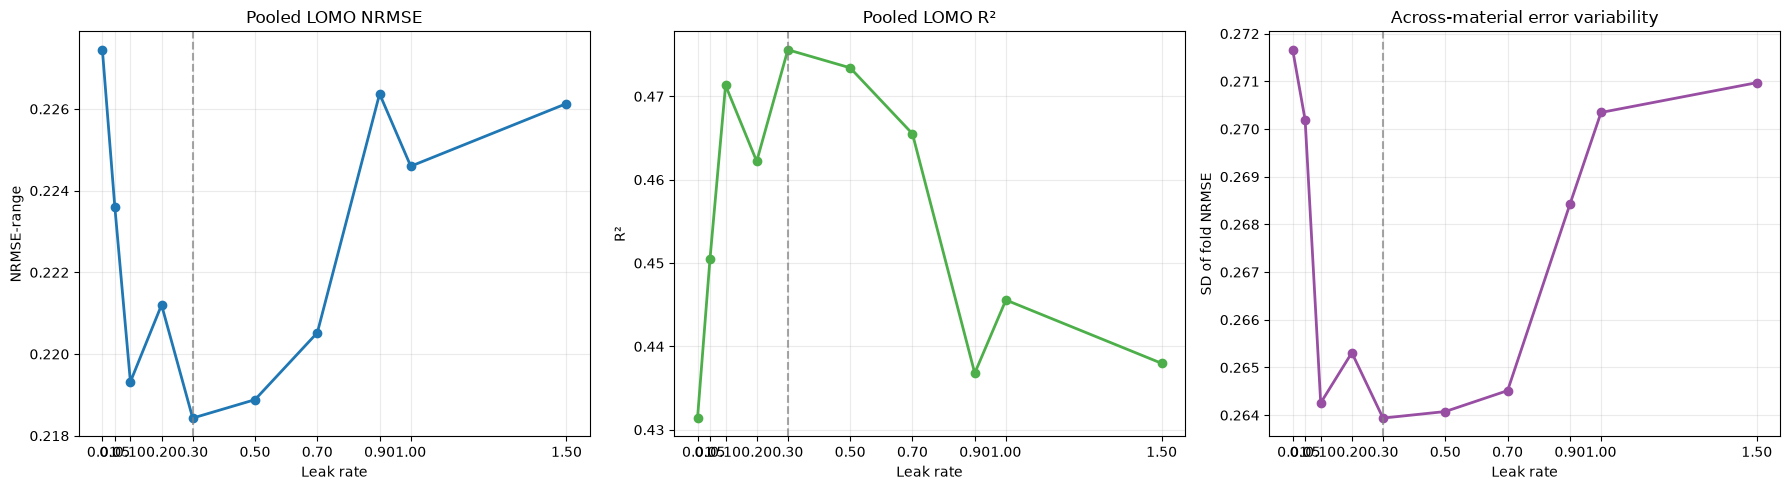

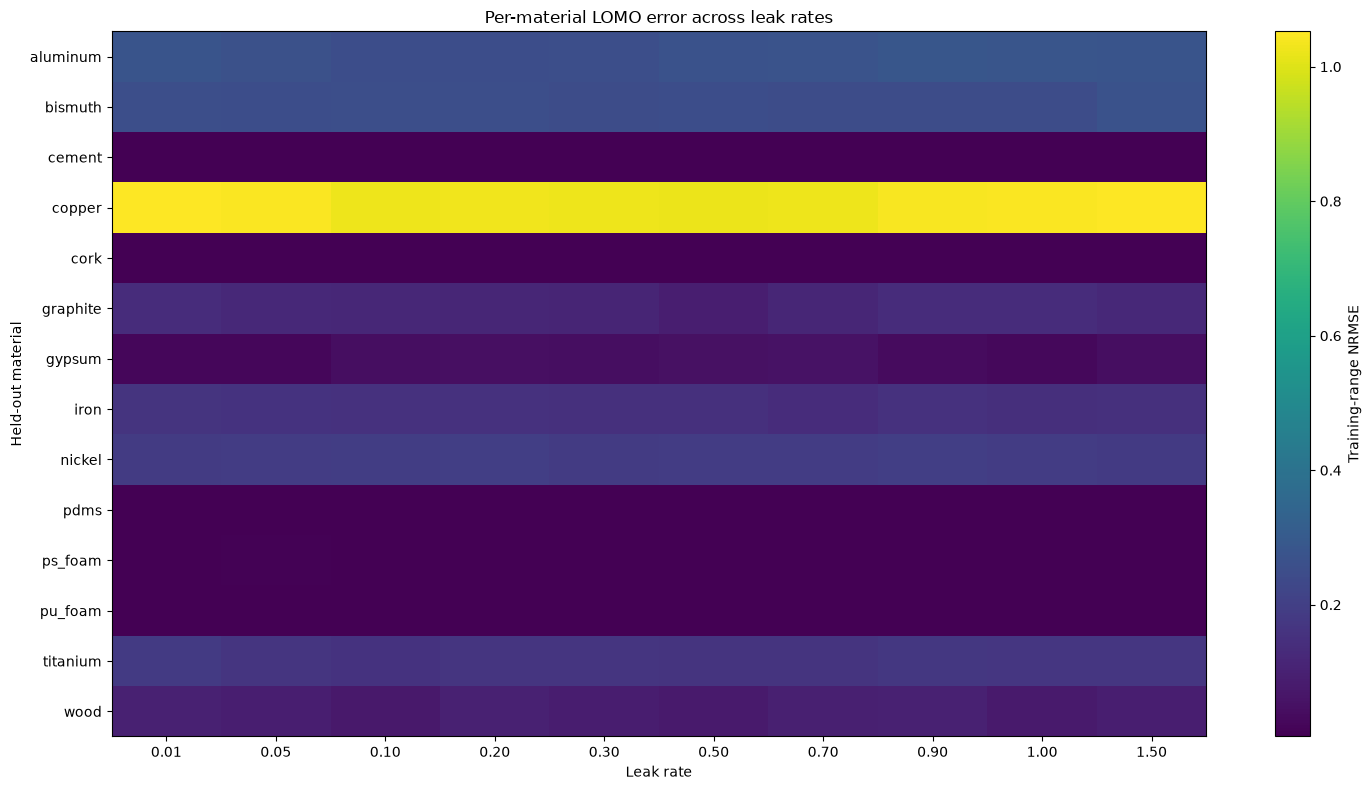

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(OVERALL["leak_rate"], OVERALL["nrmse_range"], "o-", linewidth=2)
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE-range")
axes[1].plot(OVERALL["leak_rate"], OVERALL["r2"], "o-", color="#4daf4a", linewidth=2)
axes[1].set(title="Pooled LOMO R²", ylabel="R²")
axes[2].plot(OVERALL["leak_rate"], OVERALL["fold_nrmse_sd"], "o-", color="#984ea3", linewidth=2)
axes[2].set(title="Across-material error variability", ylabel="SD of fold NRMSE")
for ax in axes:
    ax.set_xlabel("Leak rate")
    ax.axvline(best["leak_rate"], color="gray", linestyle="--", alpha=.7)
    ax.set_xticks(LEAK_RATE_VALUES)
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

heatmap = FOLD_METRICS.pivot(
    index="held_out_material", columns="leak_rate", values="nrmse_training_range"
)[list(LEAK_RATE_VALUES)]
fig, ax = plt.subplots(figsize=(15, 8))
image = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)), [f"{x:.2f}" for x in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_xlabel("Leak rate")
ax.set_ylabel("Held-out material")
ax.set_title("Per-material LOMO error across leak rates")
fig.colorbar(image, ax=ax, label="Training-range NRMSE")
plt.tight_layout()
plt.show()


# 9. Prediction behavior for customizable case-study materials


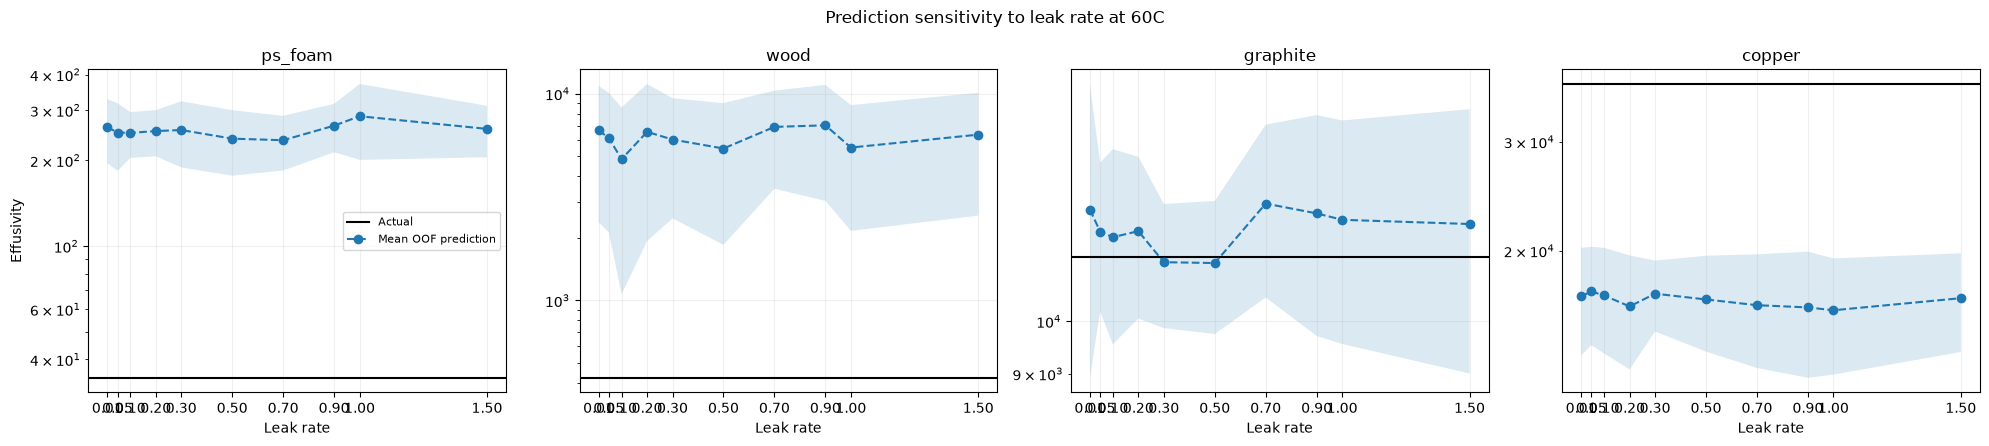

In [25]:
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["ps_foam", "wood", "graphite", "copper"]

case = (
    OOF[(OOF["Temperature"] == CASE_STUDY_TEMPERATURE) & OOF["Sample"].isin(CASE_STUDY_MATERIALS)]
    .groupby(["leak_rate", "Sample"], as_index=False)
    .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"), prediction_sd=("y_pred", "std"))
)

fig, axes = plt.subplots(1, len(CASE_STUDY_MATERIALS), figsize=(20, 4.5), sharex=True)
for ax, material in zip(axes, CASE_STUDY_MATERIALS):
    part = case[case["Sample"] == material].sort_values("leak_rate")
    if part.empty:
        ax.set_visible(False)
        continue
    ax.axhline(part["y_true"].iloc[0], color="black", label="Actual")
    ax.plot(part["leak_rate"], part["y_pred"], "o--", label="Mean OOF prediction")
    ax.fill_between(
        part["leak_rate"], part["y_pred"] - part["prediction_sd"],
        part["y_pred"] + part["prediction_sd"], alpha=.16,
    )
    ax.set_yscale("log")
    ax.set_title(material)
    ax.set_xlabel("Leak rate")
    ax.set_xticks(LEAK_RATE_VALUES)
    ax.grid(alpha=.2)
axes[0].set_ylabel("Effusivity")
axes[0].legend(fontsize=8)
fig.suptitle(f"Prediction sensitivity to leak rate at {CASE_STUDY_TEMPERATURE}")
plt.tight_layout()
plt.show()


# 10. Collective ESN dynamics across selected leak rates


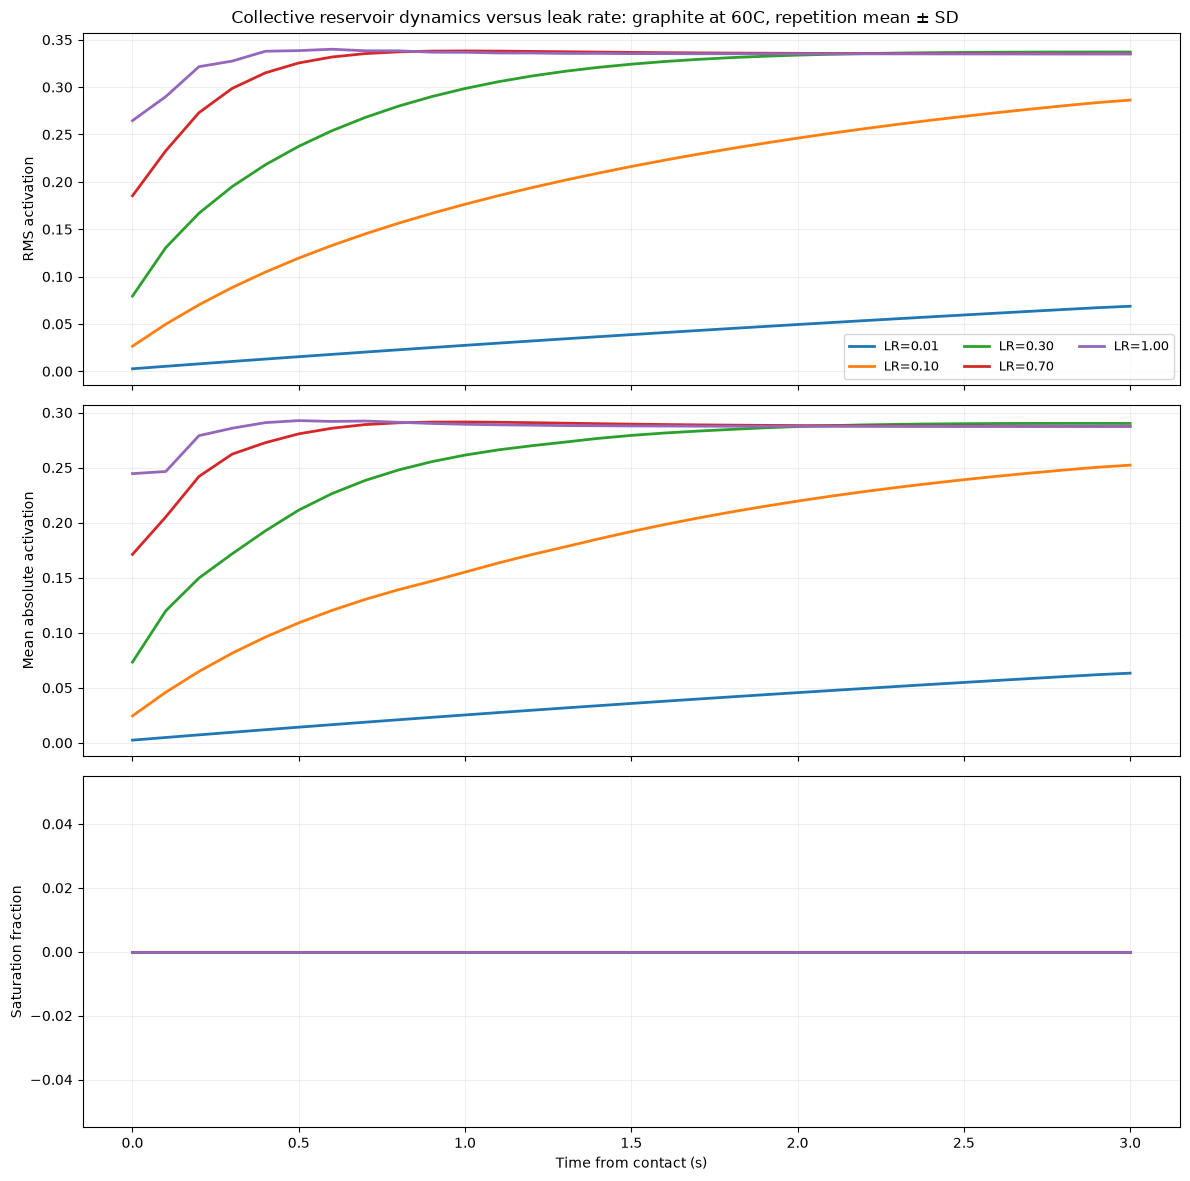

In [26]:
DYNAMICS_MATERIAL = "graphite"
DYNAMICS_TEMPERATURE = "60C"
DYNAMICS_LEAK_RATES = (0.01, 0.10, 0.30, 0.70, 1.00)
DYNAMICS_SEED = 42

selected = METADATA[
    (METADATA["Sample"] == DYNAMICS_MATERIAL)
    & (METADATA["Temperature"] == DYNAMICS_TEMPERATURE)
].sort_values("Trial")
if selected.empty:
    raise KeyError("Requested dynamics material/temperature was not found.")

common_time = np.linspace(*ANALYSIS_WINDOW, 61)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for leak_rate in DYNAMICS_LEAK_RATES:
    if leak_rate not in LEAK_RATE_VALUES:
        raise KeyError(f"LR={leak_rate} was not declared in LEAK_RATE_VALUES.")
    reservoir = ManualReservoir(leak_rate=leak_rate, random_state=DYNAMICS_SEED)
    rms_trials, mean_abs_trials, saturation_trials = [], [], []
    for trial_id in selected["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        rms_trials.append(np.interp(common_time, state_time, np.sqrt(np.mean(states ** 2, axis=1))))
        mean_abs_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states), axis=1)))
        saturation_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states) >= .95, axis=1)))

    for ax, trials, label in zip(
        axes, (rms_trials, mean_abs_trials, saturation_trials),
        ("RMS activation", "Mean absolute activation", "Saturation fraction"),
    ):
        trials = np.asarray(trials)
        mean, sd = trials.mean(axis=0), trials.std(axis=0, ddof=1)
        ax.plot(common_time, mean, linewidth=2, label=f"LR={leak_rate:.2f}")
        ax.fill_between(common_time, mean - sd, mean + sd, alpha=.10)
        ax.set_ylabel(label)
        ax.grid(alpha=.2)

axes[-1].set_xlabel("Time from contact (s)")
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle(
    f"Collective reservoir dynamics versus leak rate: {DYNAMICS_MATERIAL} at "
    f"{DYNAMICS_TEMPERATURE}, repetition mean ± SD"
)
plt.tight_layout()
plt.show()


# 11. Explicit leak-rate → ESN-dynamics relationship

The physical input is repeated across columns because only the leak rate changes.
The lower row follows the **same reservoir units** at every leak rate: reservoir size,
random seed, input weights, and recurrent weights remain fixed. Consequently, changes
in trajectory speed, persistence, curvature, or amplitude can be attributed directly
to the leak-rate state-update weighting.

The table adds three complementary diagnostics:

- **mean state-step magnitude:** how much activation changes per retained sample;
- **lag-one state correlation:** how strongly each state resembles its preceding state;
- **input–state coupling:** the mean, across units, of the strongest absolute
  zero-lag correlation with any of the five ESN input channels.


,leak_rate,previous_state_weight,proposed_state_weight,mean_state_step_magnitude,mean_lag1_state_correlation,mean_max_abs_input_state_correlation
0,0.01,0.99,0.01,0.001014,0.999998,0.966799
1,0.10,0.90,0.10,0.004362,0.998835,0.939669
2,0.30,0.70,0.30,0.004872,0.990921,0.881177
3,0.70,0.30,0.70,0.004424,0.977036,0.798130
4,1.00,0.00,1.00,0.007654,0.802916,0.566986


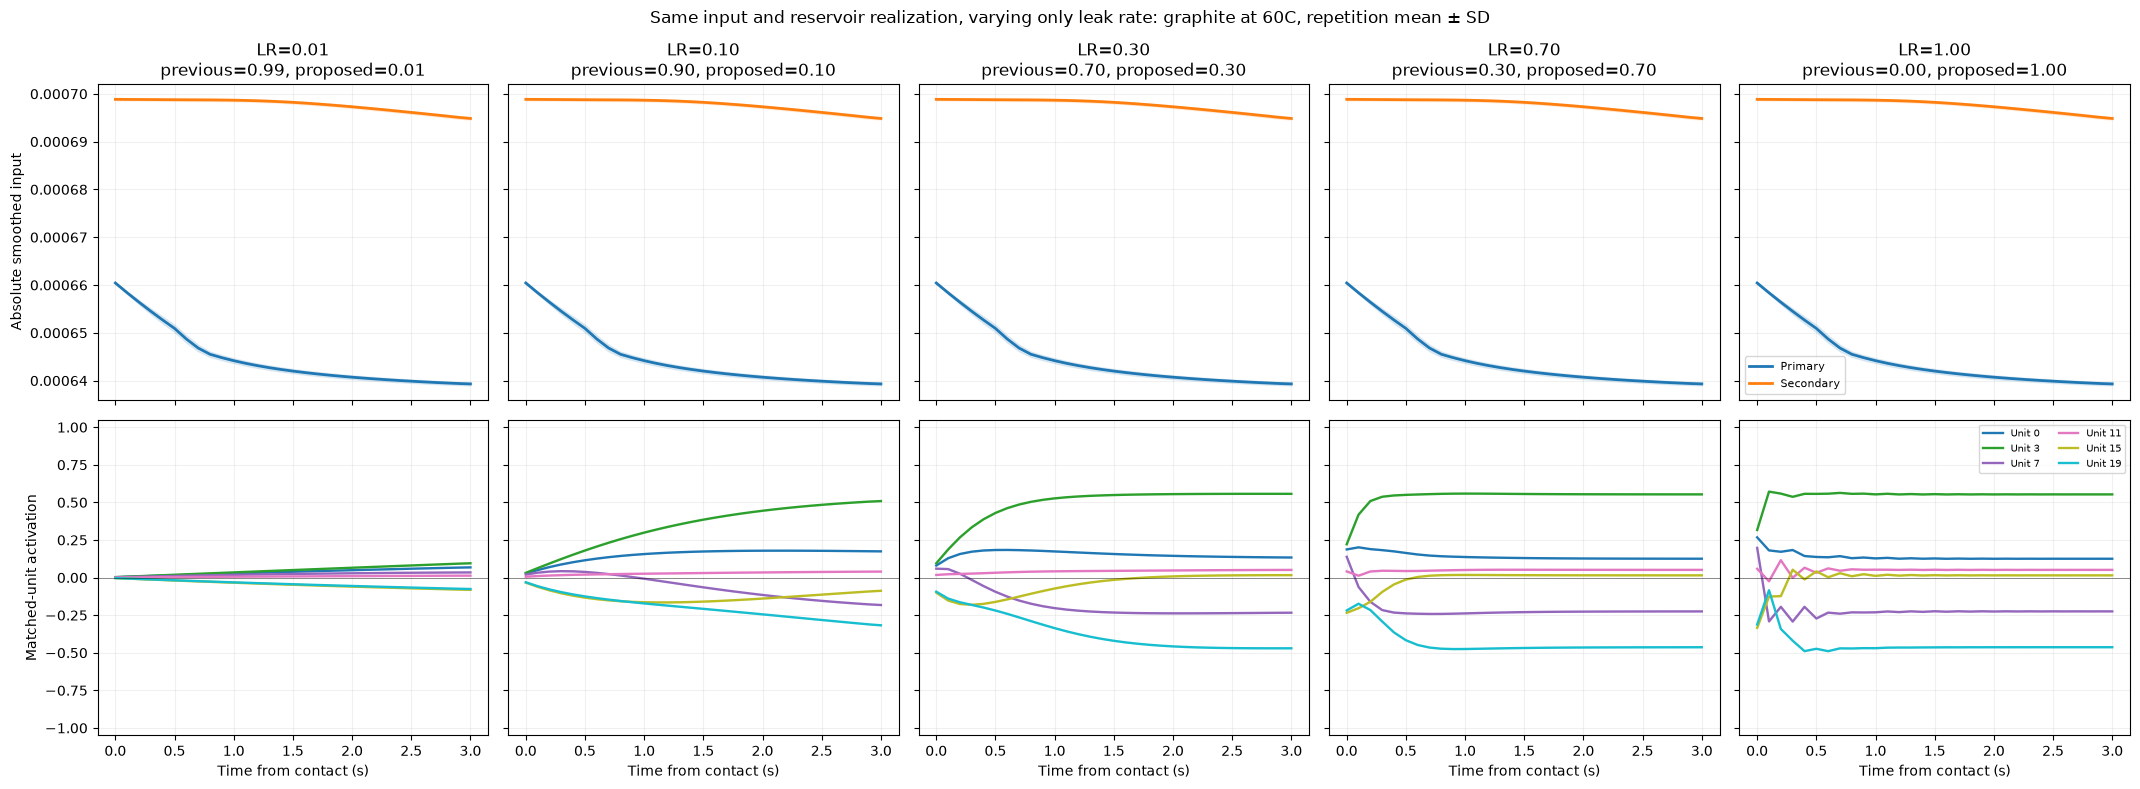

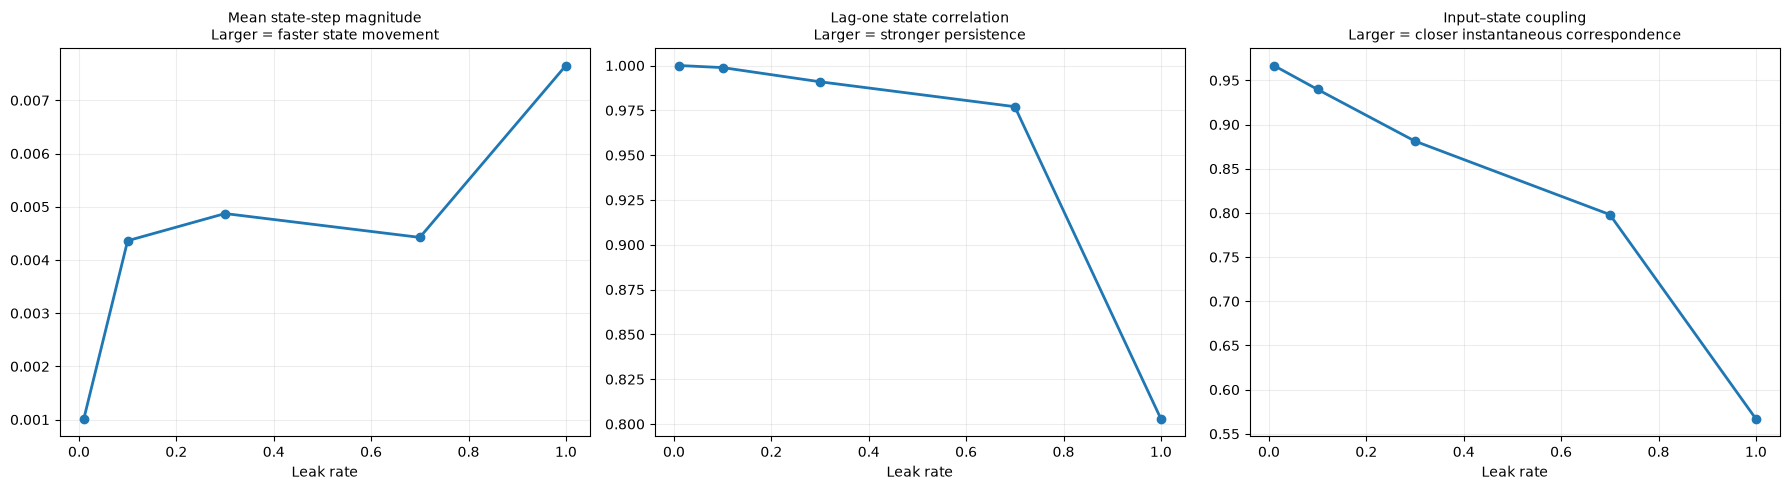

In [27]:
# Edit these without changing the prediction experiment above.
RELATIONSHIP_LEAK_RATES = DYNAMICS_LEAK_RATES
RELATIONSHIP_UNITS = (0, 3, 7, 11, 15, 19)

if any(unit >= FIXED_ESN_PARAMS["res_size"] for unit in RELATIONSHIP_UNITS):
    raise IndexError("RELATIONSHIP_UNITS contains an index outside the fixed reservoir.")


def resample_trial_input_and_states(trial_id, leak_rate, seed, target_time):
    trial = aligned_trials[trial_id]
    time_values = trial["time_from_contact"].to_numpy(float)
    inputs = esn_input(trial)
    reservoir = ManualReservoir(leak_rate=leak_rate, random_state=seed)
    states = reservoir.run(inputs)
    state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
    input_resampled = np.column_stack([
        np.interp(target_time, time_values, inputs[:, channel])
        for channel in range(inputs.shape[1])
    ])
    state_resampled = np.column_stack([
        np.interp(target_time, state_time, states[:, unit])
        for unit in range(states.shape[1])
    ])
    return input_resampled, state_resampled


RELATIONSHIP_INPUT_CUBES = {}
RELATIONSHIP_STATE_CUBES = {}
relationship_rows = []

for leak_rate in RELATIONSHIP_LEAK_RATES:
    input_repetitions, state_repetitions = [], []
    for trial_id in selected["trial_id"]:
        input_values, state_values = resample_trial_input_and_states(
            trial_id, leak_rate, DYNAMICS_SEED, common_time
        )
        input_repetitions.append(input_values)
        state_repetitions.append(state_values)
    input_cube = np.asarray(input_repetitions)  # repetition × time × channel
    state_cube = np.asarray(state_repetitions)  # repetition × time × unit
    RELATIONSHIP_INPUT_CUBES[leak_rate] = input_cube
    RELATIONSHIP_STATE_CUBES[leak_rate] = state_cube

    mean_inputs = input_cube.mean(axis=0)
    mean_states = state_cube.mean(axis=0)
    mean_step = float(np.mean(np.abs(np.diff(mean_states, axis=0))))

    lag_correlations = []
    input_state_couplings = []
    for unit in range(mean_states.shape[1]):
        current, previous = mean_states[1:, unit], mean_states[:-1, unit]
        if np.std(current) > 1e-12 and np.std(previous) > 1e-12:
            lag_correlations.append(float(np.corrcoef(previous, current)[0, 1]))
        channel_correlations = []
        for channel in range(mean_inputs.shape[1]):
            if np.std(mean_states[:, unit]) > 1e-12 and np.std(mean_inputs[:, channel]) > 1e-12:
                channel_correlations.append(
                    abs(float(np.corrcoef(mean_inputs[:, channel], mean_states[:, unit])[0, 1]))
                )
        if channel_correlations:
            input_state_couplings.append(max(channel_correlations))

    relationship_rows.append({
        "leak_rate": float(leak_rate),
        "previous_state_weight": float(1 - leak_rate),
        "proposed_state_weight": float(leak_rate),
        "mean_state_step_magnitude": mean_step,
        "mean_lag1_state_correlation": float(np.mean(lag_correlations)),
        "mean_max_abs_input_state_correlation": float(np.mean(input_state_couplings)),
    })

LR_DYNAMICS_RELATIONSHIP = pd.DataFrame(relationship_rows)
display(LR_DYNAMICS_RELATIONSHIP)


fig, axes = plt.subplots(
    2, len(RELATIONSHIP_LEAK_RATES),
    figsize=(4.3 * len(RELATIONSHIP_LEAK_RATES), 8),
    sharex=True, sharey="row",
)
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(RELATIONSHIP_UNITS)))

for column, leak_rate in enumerate(RELATIONSHIP_LEAK_RATES):
    input_cube = RELATIONSHIP_INPUT_CUBES[leak_rate]
    state_cube = RELATIONSHIP_STATE_CUBES[leak_rate]
    input_mean, input_sd = input_cube.mean(axis=0), input_cube.std(axis=0, ddof=1)
    state_mean, state_sd = state_cube.mean(axis=0), state_cube.std(axis=0, ddof=1)

    top, bottom = axes[0, column], axes[1, column]
    for channel, label, color in ((0, "Primary", "#1f77b4"), (1, "Secondary", "#ff7f0e")):
        top.plot(common_time, input_mean[:, channel], color=color, linewidth=2, label=label)
        top.fill_between(
            common_time, input_mean[:, channel] - input_sd[:, channel],
            input_mean[:, channel] + input_sd[:, channel], color=color, alpha=.12,
        )
    top.set_title(
        f"LR={leak_rate:.2f}\nprevious={1-leak_rate:.2f}, proposed={leak_rate:.2f}"
    )
    top.grid(alpha=.18)

    for color, unit in zip(unit_colors, RELATIONSHIP_UNITS):
        bottom.plot(common_time, state_mean[:, unit], color=color, linewidth=1.7, label=f"Unit {unit}")
        bottom.fill_between(
            common_time, state_mean[:, unit] - state_sd[:, unit],
            state_mean[:, unit] + state_sd[:, unit], color=color, alpha=.08,
        )
    bottom.axhline(0, color="black", linewidth=.6, alpha=.5)
    bottom.set_ylim(-1.05, 1.05)
    bottom.set_xlabel("Time from contact (s)")
    bottom.grid(alpha=.18)

axes[0, 0].set_ylabel("Absolute smoothed input")
axes[1, 0].set_ylabel("Matched-unit activation")
axes[0, -1].legend(fontsize=8, loc="best")
axes[1, -1].legend(fontsize=7, ncol=2, loc="best")
fig.suptitle(
    f"Same input and reservoir realization, varying only leak rate: "
    f"{DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, repetition mean ± SD"
)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
relationship_diagnostics = (
    ("mean_state_step_magnitude", "Mean state-step magnitude", "Larger = faster state movement"),
    ("mean_lag1_state_correlation", "Lag-one state correlation", "Larger = stronger persistence"),
    ("mean_max_abs_input_state_correlation", "Input–state coupling", "Larger = closer instantaneous correspondence"),
)
for ax, (column, title, subtitle) in zip(axes, relationship_diagnostics):
    ax.plot(LR_DYNAMICS_RELATIONSHIP["leak_rate"], LR_DYNAMICS_RELATIONSHIP[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Leak rate")
    ax.grid(alpha=.22)
plt.tight_layout()
plt.show()


# 12. Unit-level trajectories, heatmaps, and dynamic-complexity diagnostics

Because reservoir size and seed are fixed, unit indices correspond across leak-rate
conditions in this study. Each condition shows all 20 repetition-mean trajectories,
the mean-state heatmap, and the repetition-SD heatmap. The table quantifies unit
redundancy, effective rank, temporal variation, repeatability, and saturation.


,leak_rate,n_repetitions,mean_abs_unit_correlation,effective_rank,effective_rank_fraction,pca_dimensions_95pct,pca95_fraction_of_units,mean_unit_temporal_sd,mean_repetition_sd,saturation_fraction,mean_absolute_activation
0,0.01,6,0.996135,1.009621,0.050481,1,0.05,0.017932,0.000018,0.0,0.034822
1,0.10,6,0.789329,1.234878,0.061744,2,0.10,0.071909,0.000041,0.0,0.176284
2,0.30,6,0.690008,1.268008,0.063400,2,0.10,0.073731,0.000005,0.0,0.253802
3,0.70,6,0.784430,1.323723,0.066186,2,0.10,0.049293,0.000002,0.0,0.279881
4,1.00,6,0.664863,1.821169,0.091058,2,0.10,0.043476,0.000003,0.0,0.285277


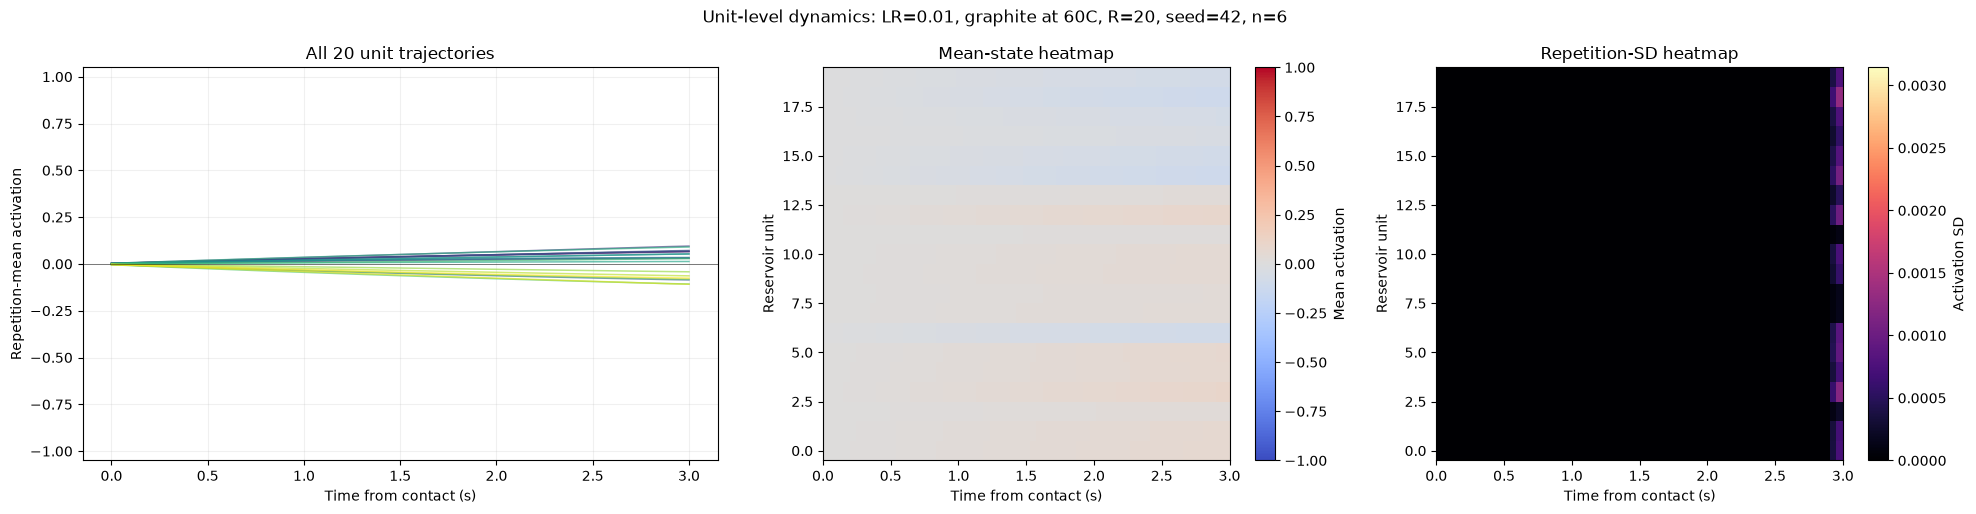

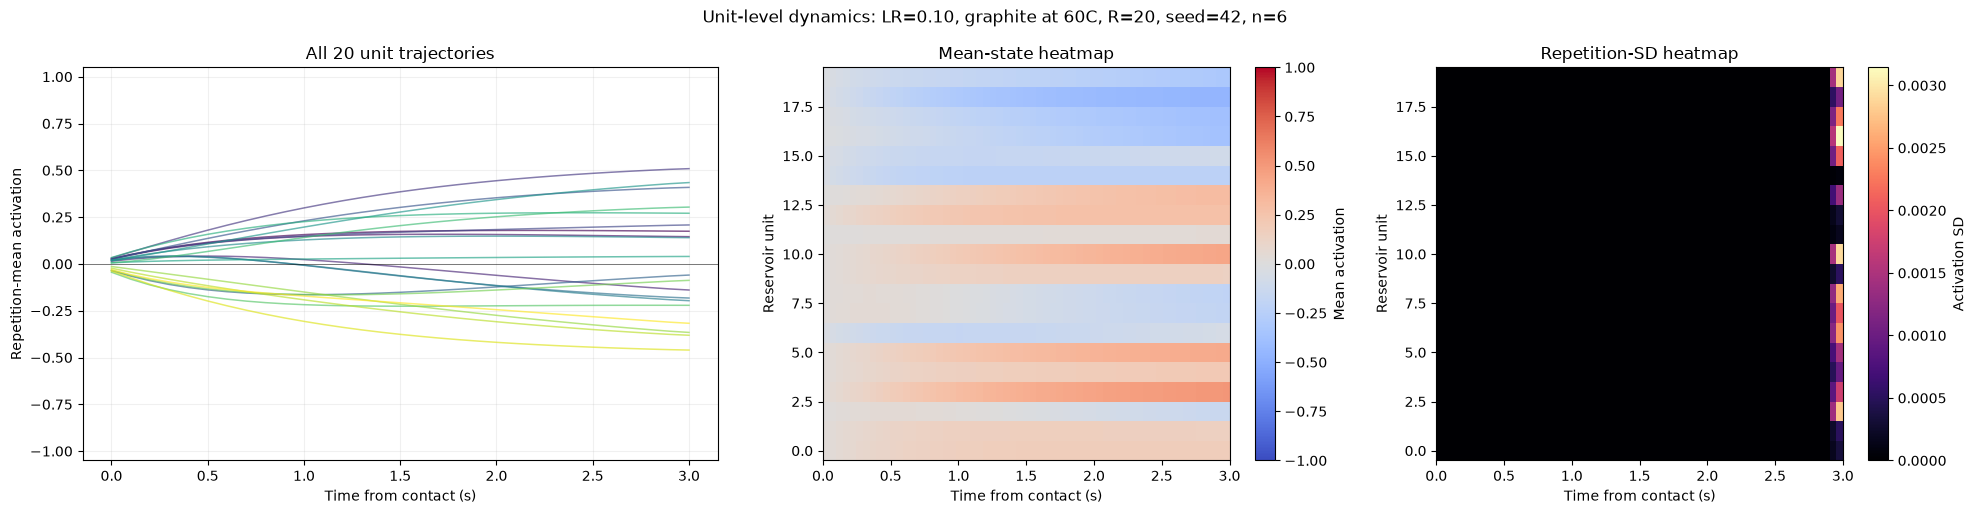

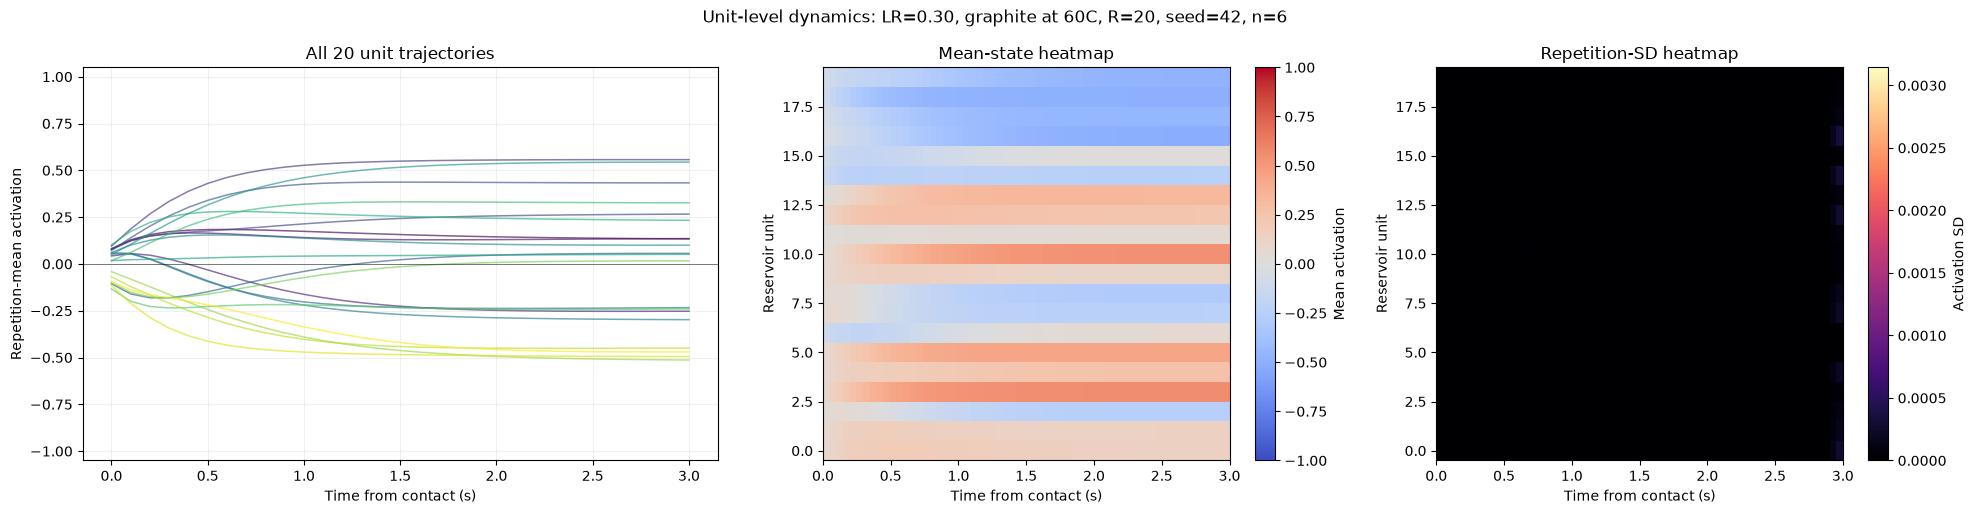

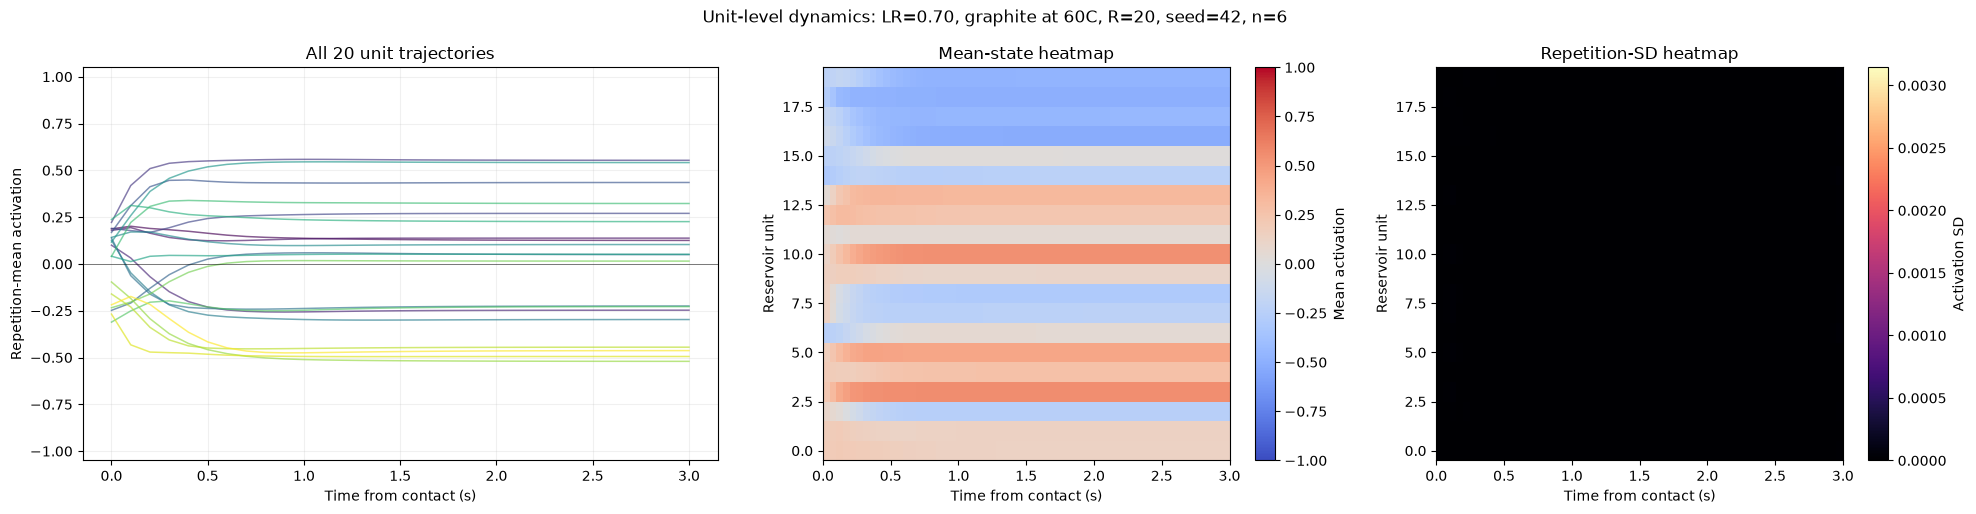

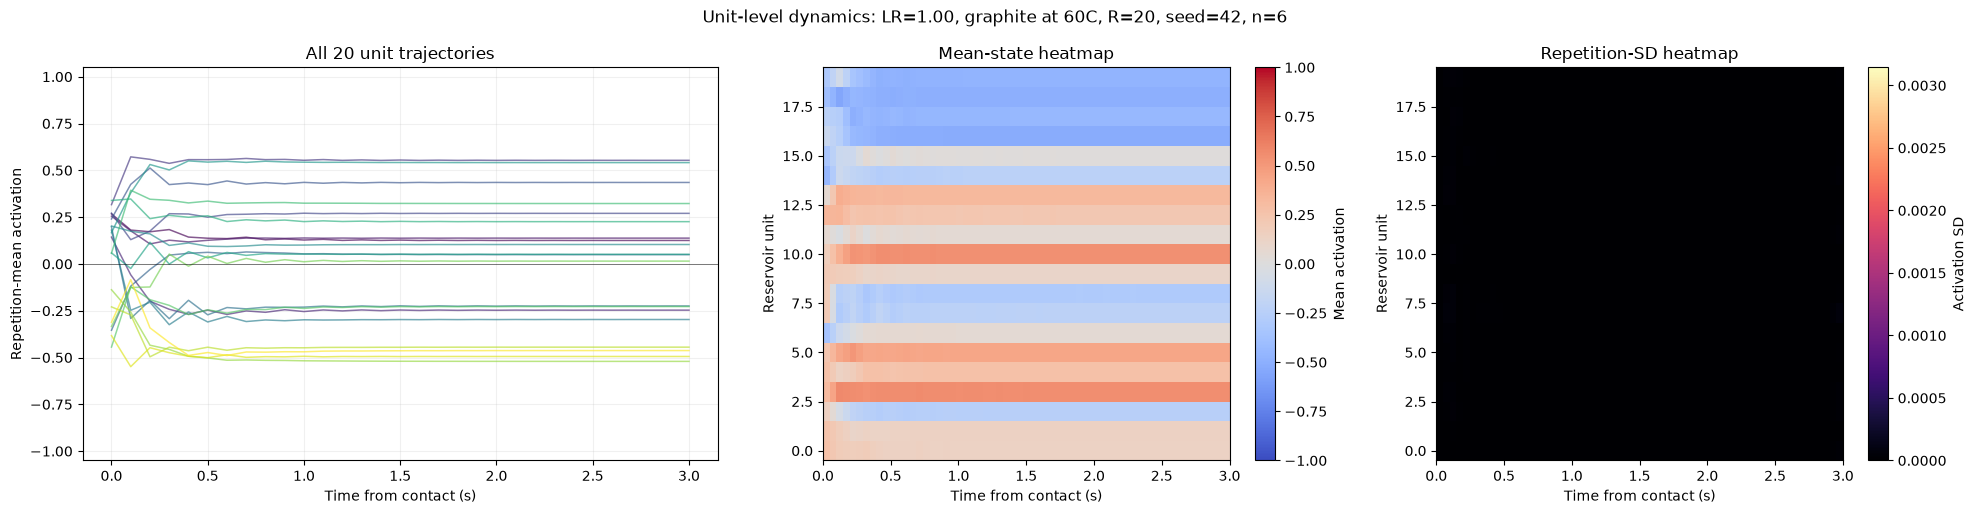

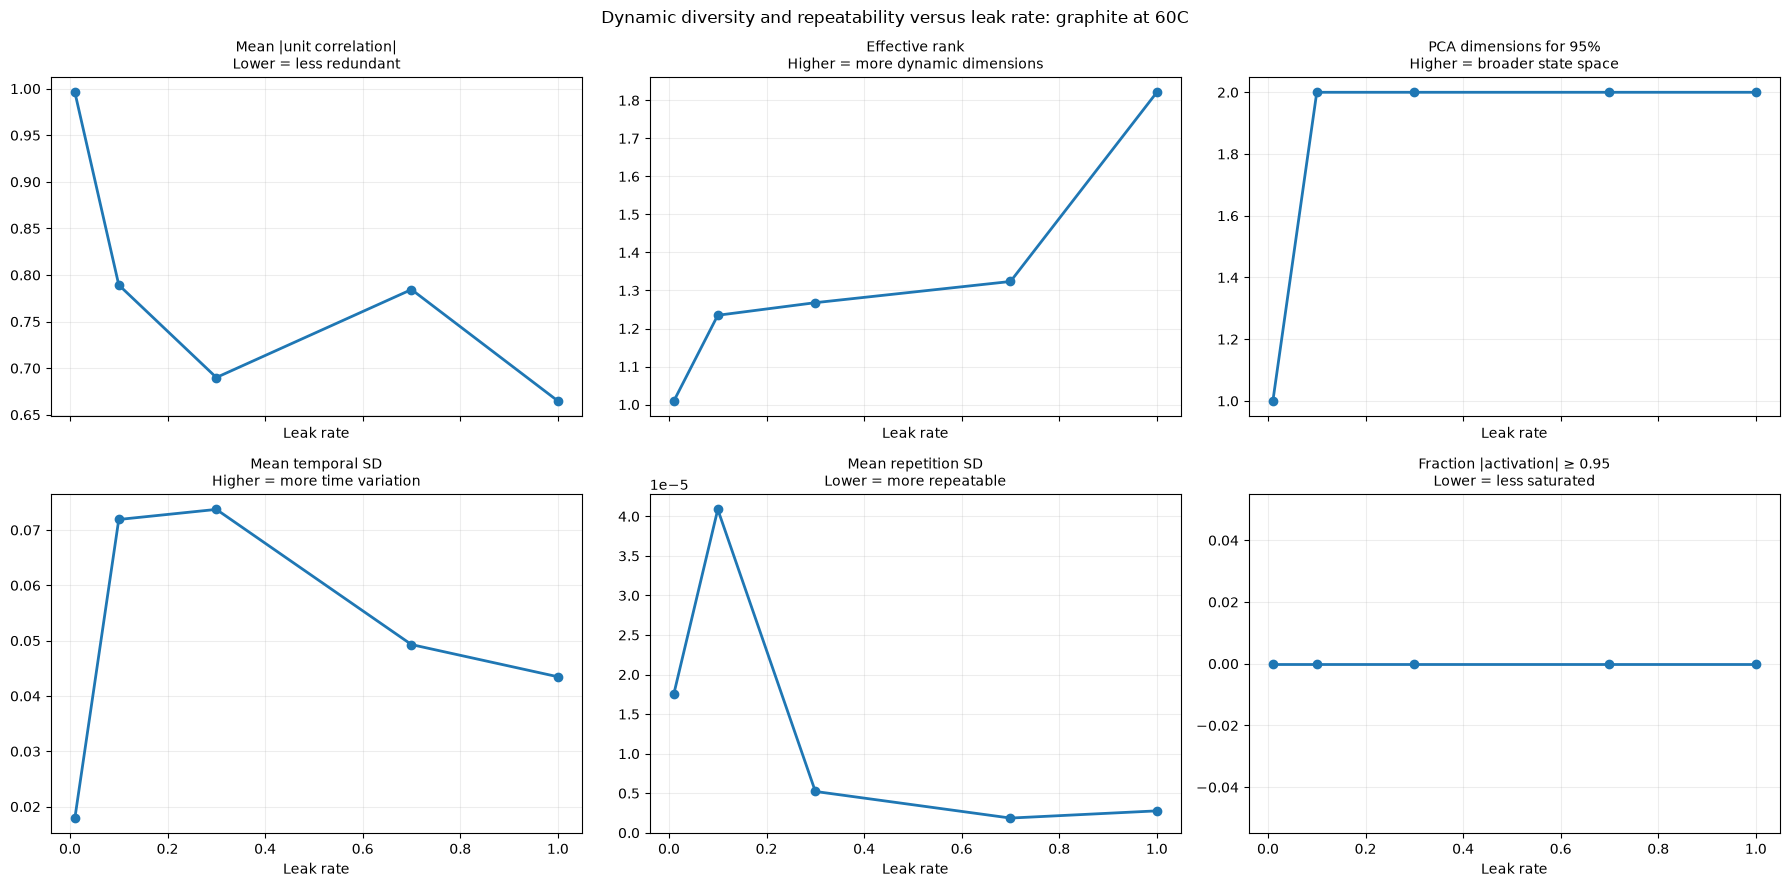

In [28]:
SATURATION_THRESHOLD = 0.95
PCA_VARIANCE_THRESHOLD = 0.95


def collect_resampled_states(leak_rate, selected_metadata, seed, target_time):
    reservoir = ManualReservoir(leak_rate=leak_rate, random_state=seed)
    repetitions, trial_ids = [], []
    for trial_id in selected_metadata["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        repetitions.append(np.column_stack([
            np.interp(target_time, state_time, states[:, unit])
            for unit in range(states.shape[1])
        ]))
        trial_ids.append(trial_id)
    return np.asarray(repetitions), trial_ids


def state_complexity_metrics(state_cube, leak_rate):
    state_cube = np.asarray(state_cube, float)
    repetition_mean = state_cube.mean(axis=0)
    centered = repetition_mean - repetition_mean.mean(axis=0, keepdims=True)
    valid = np.std(repetition_mean, axis=0) > 1e-12
    if valid.sum() >= 2:
        correlation = np.corrcoef(repetition_mean[:, valid], rowvar=False)
        off_diagonal = correlation[np.triu_indices_from(correlation, k=1)]
        mean_abs_correlation = float(np.nanmean(np.abs(off_diagonal)))
    else:
        mean_abs_correlation = np.nan
    singular_values = np.linalg.svd(centered, full_matrices=False, compute_uv=False)
    singular_values = singular_values[singular_values > 1e-12]
    if len(singular_values):
        energy_fraction = singular_values ** 2 / np.sum(singular_values ** 2)
        effective_rank = float(np.exp(-np.sum(energy_fraction * np.log(energy_fraction))))
        pca_dimensions_95 = int(np.searchsorted(np.cumsum(energy_fraction), PCA_VARIANCE_THRESHOLD) + 1)
    else:
        effective_rank, pca_dimensions_95 = 0.0, 0
    repetition_sd = state_cube.std(axis=0, ddof=1) if len(state_cube) > 1 else np.zeros_like(repetition_mean)
    return {
        "leak_rate": float(leak_rate), "n_repetitions": int(len(state_cube)),
        "mean_abs_unit_correlation": mean_abs_correlation,
        "effective_rank": effective_rank,
        "effective_rank_fraction": effective_rank / min(repetition_mean.shape),
        "pca_dimensions_95pct": pca_dimensions_95,
        "pca95_fraction_of_units": pca_dimensions_95 / FIXED_ESN_PARAMS["res_size"],
        "mean_unit_temporal_sd": float(np.mean(repetition_mean.std(axis=0, ddof=0))),
        "mean_repetition_sd": float(np.mean(repetition_sd)),
        "saturation_fraction": float(np.mean(np.abs(state_cube) >= SATURATION_THRESHOLD)),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    }


UNIT_STATE_CUBES, UNIT_STATE_TRIAL_IDS, rows = {}, {}, []
for leak_rate in DYNAMICS_LEAK_RATES:
    cube, trial_ids = collect_resampled_states(leak_rate, selected, DYNAMICS_SEED, common_time)
    UNIT_STATE_CUBES[leak_rate] = cube
    UNIT_STATE_TRIAL_IDS[leak_rate] = trial_ids
    rows.append(state_complexity_metrics(cube, leak_rate))
DYNAMICS_COMPLEXITY = pd.DataFrame(rows)
display(DYNAMICS_COMPLEXITY)

all_sd = [cube.std(axis=0, ddof=1) for cube in UNIT_STATE_CUBES.values()]
sd_color_max = max(float(np.nanmax(x)) for x in all_sd)
if not np.isfinite(sd_color_max) or np.isclose(sd_color_max, 0):
    sd_color_max = 1.0

res_size = FIXED_ESN_PARAMS["res_size"]
for leak_rate in DYNAMICS_LEAK_RATES:
    cube = UNIT_STATE_CUBES[leak_rate]
    mean_states = cube.mean(axis=0)
    sd_states = cube.std(axis=0, ddof=1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]})
    colors = plt.cm.viridis(np.linspace(0, 1, res_size))
    for unit in range(res_size):
        axes[0].plot(common_time, mean_states[:, unit], color=colors[unit], linewidth=1.1, alpha=.65)
    axes[0].axhline(0, color="black", linewidth=.7, alpha=.5)
    axes[0].set(title=f"All {res_size} unit trajectories", xlabel="Time from contact (s)", ylabel="Repetition-mean activation", ylim=(-1.05, 1.05))
    axes[0].grid(alpha=.18)
    im0 = axes[1].imshow(mean_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    axes[1].set(title="Mean-state heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im0, ax=axes[1], label="Mean activation")
    im1 = axes[2].imshow(sd_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="magma", vmin=0, vmax=sd_color_max, interpolation="nearest")
    axes[2].set(title="Repetition-SD heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im1, ax=axes[2], label="Activation SD")
    fig.suptitle(f"Unit-level dynamics: LR={leak_rate:.2f}, {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, R={res_size}, seed={DYNAMICS_SEED}, n={len(cube)}")
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
diagnostics = (
    ("mean_abs_unit_correlation", "Mean |unit correlation|", "Lower = less redundant"),
    ("effective_rank", "Effective rank", "Higher = more dynamic dimensions"),
    ("pca_dimensions_95pct", "PCA dimensions for 95%", "Higher = broader state space"),
    ("mean_unit_temporal_sd", "Mean temporal SD", "Higher = more time variation"),
    ("mean_repetition_sd", "Mean repetition SD", "Lower = more repeatable"),
    ("saturation_fraction", "Fraction |activation| ≥ 0.95", "Lower = less saturated"),
)
for ax, (column, title, subtitle) in zip(axes.ravel(), diagnostics):
    ax.plot(DYNAMICS_COMPLEXITY["leak_rate"], DYNAMICS_COMPLEXITY[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10); ax.set_xlabel("Leak rate"); ax.grid(alpha=.22)
fig.suptitle(f"Dynamic diversity and repeatability versus leak rate: {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}")
plt.tight_layout(); plt.show()


# 13. Save outputs and provenance


In [29]:
OVERALL_FILE = RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv"
FOLD_FILE = RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv"
OOF_FILE = RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv"
FEATURE_COUNT_FILE = RESULTS_DIR / f"{RESULT_STEM}_feature_counts.csv"
DYNAMICS_COMPLEXITY_FILE = RESULTS_DIR / f"{RESULT_STEM}_dynamics_complexity.csv"
LR_DYNAMICS_RELATIONSHIP_FILE = RESULTS_DIR / f"{RESULT_STEM}_lr_dynamics_relationship.csv"
PROVENANCE_FILE = RESULTS_DIR / f"{RESULT_STEM}_provenance.json"

OVERALL.to_csv(OVERALL_FILE, index=False)
FOLD_METRICS.to_csv(FOLD_FILE, index=False)
OOF.to_csv(OOF_FILE, index=False)
FEATURE_COUNTS.to_csv(FEATURE_COUNT_FILE, index=False)
DYNAMICS_COMPLEXITY.to_csv(DYNAMICS_COMPLEXITY_FILE, index=False)
LR_DYNAMICS_RELATIONSHIP.to_csv(LR_DYNAMICS_RELATIONSHIP_FILE, index=False)

provenance = {
    "purpose": "Controlled ESN leak-rate ablation",
    "leak_rates": list(LEAK_RATE_VALUES),
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET, "analysis_window": list(ANALYSIS_WINDOW),
    "input_preprocessing": {
        "sensor_values": "absolute processed-file Primary and Secondary values",
        "smoothing": "Savitzky-Golay", "baseline_centering": False,
        "minmax_normalization": False, "standard_scaler": False,
        "esn_channels": ["Primary", "Secondary", "Primary-Secondary", "dPrimary/dt", "dSecondary/dt"],
    },
    "regressor_inputs": ["nine summarized statistics per ESN unit", "27 scalar thermal features"],
    "temperature_used_as_regressor_feature": False,
    "fixed_esn_parameters": FIXED_ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS, "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO; 336 pooled OOF trial predictions per leak rate",
    "unit_level_dynamics": {
        "material": DYNAMICS_MATERIAL, "temperature": DYNAMICS_TEMPERATURE,
        "leak_rates": list(DYNAMICS_LEAK_RATES), "seed": DYNAMICS_SEED,
        "common_time_points": len(common_time), "saturation_threshold": SATURATION_THRESHOLD,
        "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
        "unit_indices_matched_across_conditions": True,
        "relationship_units": list(RELATIONSHIP_UNITS),
        "relationship_metrics": [
            "mean_state_step_magnitude", "mean_lag1_state_correlation",
            "mean_max_abs_input_state_correlation",
        ],
    },
    "selection_warning": "The exploratory best leak rate requires independent confirmation or nested selection.",
}
with PROVENANCE_FILE.open("w") as file:
    json.dump(provenance, file, indent=2)

print("Saved:")
for path in (OVERALL_FILE, FOLD_FILE, OOF_FILE, FEATURE_COUNT_FILE, DYNAMICS_COMPLEXITY_FILE,
    LR_DYNAMICS_RELATIONSHIP_FILE, PROVENANCE_FILE):
    print(" -", path)


Saved:
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_leak_rate_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_overall_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_leak_rate_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_fold_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_leak_rate_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_oof_predictions.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Ob

# Interpretation checklist

- Very small leak rates strongly preserve previous activity and can under-react within 3 s.
- Large leak rates follow the proposed state quickly but may reduce smoothing and memory.
- Look for an intermediate rate that balances pooled accuracy and fold stability.
- Use heatmaps and effective rank to determine whether stronger updating creates genuinely broader dynamics or merely correlated responses.
- Check repetition SD and saturation before interpreting richer trajectories as beneficial.
- Because reservoir size and seed are fixed, corresponding unit indices can be compared across leak-rate conditions.
- Treat the best leak rate as exploratory unless confirmed independently or selected inside nested validation.
